In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
sns.set_theme(style="darkgrid")

# Load data
data = pd.read_csv("Linhac24-25_Sportlogiq.csv")

print(data.isnull().sum())
data.head(10)

gameid                                0
opposingteamgoalieoniceid          3266
opposingteamid                        0
playerid                              0
teamgoalieoniceid                  7080
teamid                                0
teaminpossession                  73890
currentpossession                 73890
xg_allattempts                   525454
compiledgametime                      0
eventname                             0
ishomegame                            0
manpowersituation                     0
opposingteamskatersonicecount         0
outcome                               0
period                                0
playerprimaryposition                 0
scoredifferential                     0
teamskatersonicecount                 0
type                                  0
xadjcoord                             0
yadjcoord                             0
dtype: int64


,gameid,opposingteamgoalieoniceid,opposingteamid,playerid,teamgoalieoniceid,teamid,teaminpossession,currentpossession,xg_allattempts,compiledgametime,...,manpowersituation,opposingteamskatersonicecount,outcome,period,playerprimaryposition,scoredifferential,teamskatersonicecount,type,xadjcoord,yadjcoord
0,72393,553243.0,885,489917,172367.0,814,NaN,NaN,NaN,0.000000,...,evenStrength,5,failed,1,F,0,5,none,0.304306,0.251442
1,72393,172367.0,814,435025,553243.0,885,NaN,NaN,NaN,0.000000,...,evenStrength,5,successful,1,F,0,5,recovered,-0.304306,-0.251442
2,72393,172367.0,814,435025,553243.0,885,885.0,0.0,NaN,1.333333,...,evenStrength,5,successful,1,F,0,5,faceoffcontested,0.205826,0.245975
3,72393,553243.0,885,489917,172367.0,814,885.0,0.0,NaN,1.333333,...,evenStrength,5,failed,1,F,0,5,contested,-0.205826,-0.245975
4,72393,172367.0,814,435025,553243.0,885,885.0,0.0,NaN,2.166667,...,evenStrength,5,successful,1,F,0,5,south,3.223473,3.766563
5,72393,172367.0,814,706220,553243.0,885,885.0,0.0,NaN,2.966667,...,evenStrength,5,successful,1,D,0,5,regular,-19.911827,11.310680
6,72393,172367.0,814,706220,553243.0,885,885.0,0.0,NaN,4.466667,...,evenStrength,5,failed,1,D,0,5,north,-7.338295,26.398914
7,72393,553243.0,885,213380,172367.0,814,885.0,0.0,NaN,4.700000,...,evenStrength,5,successful,1,F,0,5,pass,1.813835,-24.897058
8,72393,553243.0,885,213380,172367.0,814,814.0,1.0,NaN,6.033333,...,evenStrength,5,successful,1,F,0,5,none,-17.800873,-40.991177
9,72393,553243.0,885,213380,172367.0,814,814.0,1.0,NaN,6.533333,...,evenStrength,5,successful,1,F,0,5,body,-16.794991,-40.488235


## Check sequence before goal

In [19]:
# Sort the data in a chronoligical order
sorted_data = data.sort_values(by=['gameid', 'compiledgametime']) 
print(sorted_data)

sorted_data['prev_event'] = sorted_data.groupby('gameid')['eventname'].shift(1) #groupby sepereates the data for different games
sorted_data['next_event'] = sorted_data.groupby('gameid')['eventname'].shift(-1)

print(sorted_data[['gameid', 'compiledgametime', 'prev_event', 'eventname', 'next_event']].head(10))


        gameid  opposingteamgoalieoniceid  opposingteamid  playerid  \
216496   60062                   170439.0             855    463268   
216497   60062                   199899.0             634    412148   
216498   60062                   170439.0             855    463268   
216499   60062                   199899.0             634    412148   
216500   60062                   199899.0             634    412148   
...        ...                        ...             ...       ...   
531165   89893                   316087.0             792    133246   
531166   89893                   316087.0             792    133246   
531167   89893                   199899.0             634    823725   
531168   89893                   316087.0             792    133246   
531169   89893                   316087.0             792    133246   

        teamgoalieoniceid  teamid  teaminpossession  currentpossession  \
216496           199899.0     634               NaN                NaN   

In [ ]:
# different approach - check which sequences generate highest xG
# only look at events in the offensive zone

pp_goals = sorted_data[
    (sorted_data['eventname'] == 'goal') & 
    (sorted_data['manpowersituation'] == 'powerPlay')
].copy()

# give each goal a unique ID
pp_goals['goal_id'] = range(len(pp_goals))

goal_lookup = pp_goals[['gameid', 'compiledgametime', 'goal_id', 'teamid']].rename(
    columns={'compiledgametime': 'goal_time', 'teamid': 'scoring_teamid'}
)
#Dataframe for only shots

sequences = pd.merge(sorted_data, goal_lookup, on='gameid')

# filter to events 20s before the goal
# only keep events from the scoring team
time_window = 20
pp_sequences = sequences[
    (sequences['compiledgametime'] <= sequences['goal_time']) & 
    (sequences['compiledgametime'] >= sequences['goal_time'] - time_window) &
    (sequences['teamid'] == sequences['scoring_teamid']) # Optional: only the attacking team
].copy()

# sort by goal and time
pp_sequences = pp_sequences.sort_values(by=['goal_id', 'compiledgametime'])

# print first goal sequence as example
print(pp_sequences[pp_sequences['goal_id'] == 0][['compiledgametime', 'eventname', 'type', 'xadjcoord', 'yadjcoord']])


In [ ]:
# Select a specific goal to visualize (e.g. goal_id 50)
goal_id_to_plot = 50
single_seq = pp_sequences[pp_sequences['goal_id'] == goal_id_to_plot]

plt.figure(figsize=(12, 4))
sns.scatterplot(data=single_seq, x='compiledgametime', y=[1]*len(single_seq), 
                hue='eventname', s=200, style='eventname')

# Add text labels for each event
for i, row in single_seq.iterrows():
    plt.text(row['compiledgametime'], 1.05, row['eventname'], 
             rotation=45, horizontalalignment='left')

plt.title(f'Event sequence before PP goal (ID: {goal_id_to_plot})')
plt.xlabel('Game time (seconds)')
plt.yticks([]) # Remove y-axis since it is not needed
plt.ylim(0.9, 1.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:

plt.figure(figsize=(12, 7))

# Draw the rink (attacking zone is to the right, x > 25)
# Blue line at x = 25, center line at x = 0, goal line at x = 89
plt.axvline(0, color='red', linewidth=2, alpha=0.5)  # Center line
plt.axvline(25, color='blue', linewidth=2, alpha=0.5) # Blue line
plt.axvline(89, color='red', linewidth=1, alpha=0.3)  # Goal line

# Plot the puck path
plt.plot(single_seq['xadjcoord'], single_seq['yadjcoord'], 
         color='black', linestyle='-', alpha=0.3, zorder=1)

# Plot events
sns.scatterplot(data=single_seq, x='xadjcoord', y='yadjcoord', 
                hue='eventname', s=150, zorder=3, palette='viridis')

# Highlight the goal clearly
goal_row = single_seq[single_seq['eventname'] == 'goal']
if not goal_row.empty:
    plt.scatter(goal_row['xadjcoord'], goal_row['yadjcoord'], 
                color='red', marker='*', s=600, label='GOAL', zorder=5, edgecolors='black')

# Set limits for the attacking zone (+ a bit of the neutral zone)
plt.xlim(-100, 100) 
plt.ylim(-42.5, 42.5)

plt.title('PP Goal Sequence: From Zone Entry to Goal', fontsize=15)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.2)
plt.show()

### Cluster different sequences

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

def create_cluster_features(df_sequences):
    # aggregate features per goal sequence
    features = df_sequences.groupby('goal_id').agg({
        'xadjcoord': ['mean', 'std', 'min'], # depth
        'yadjcoord': ['mean', 'std'],        # width / spread
        'eventname': [
            lambda x: (x == 'pass').sum(),   # passes
            lambda x: (x == 'carry').sum(),  # carries
            'count'                          # total events
        ],
        'compiledgametime': lambda x: x.max() - x.min() # duration in seconds
    })

    features.columns = [
        'x_mean', 'x_std', 'x_min', 
        'y_mean', 'y_std', 
        'num_passes', 'num_carries', 'total_events', 
        'duration'
    ]
    
    return features.fillna(0)

features_df = create_cluster_features(pp_sequences)

#  PREPROCESSING AND CLUSTERING
# scale features - K-Means is distance based so this matters
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features_df)

# start with 3 clusters
num_clusters = 3
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
features_df['cluster'] = kmeans.fit_predict(scaled_features)

pp_sequences = pp_sequences.merge(features_df[['cluster']], on='goal_id', how='left')


# CLUSTER ANALYSIS AND VISUALIZATION

cluster_interpretation = features_df.groupby('cluster').mean()
print("Average features per cluster:")
print(cluster_interpretation.round(2))

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=features_df, 
    x='num_passes', 
    y='duration', 
    hue='cluster', 
    palette='viridis', 
    s=100, 
    style='cluster'
)
plt.title('Goal sequence clusters: Passing pace vs Duration')
plt.xlabel('Number of passes before goal')
plt.ylabel('Sequence duration (seconds)')
plt.legend(title='Cluster ID')
plt.show()


#  EXAMPLE: PLOT A TYPICAL GOAL FROM EACH CLUSTER

fig, axes = plt.subplots(1, num_clusters, figsize=(18, 5))

for i in range(num_clusters):
    example_goal_id = features_df[features_df['cluster'] == i].index[0]
    example_seq = pp_sequences[pp_sequences['goal_id'] == example_goal_id]
    
    ax = axes[i]
    ax.axvline(25, color='blue', alpha=0.3) # Blue line
    ax.axvline(89, color='red', alpha=0.3)  # Goal line
    
    ax.plot(example_seq['xadjcoord'], example_seq['yadjcoord'], color='black', alpha=0.3)
    sns.scatterplot(data=example_seq, x='xadjcoord', y='yadjcoord', hue='eventname', ax=ax, s=80, legend=False)
    
    goal_row = example_seq[example_seq['eventname'] == 'goal']
    ax.scatter(goal_row['xadjcoord'], goal_row['yadjcoord'], color='red', marker='*', s=200)
    
    ax.set_title(f'Cluster {i}: Example sequence')
    ax.set_xlim(20, 100) # attacking zone
    ax.set_ylim(-42.5, 42.5)

plt.tight_layout()
plt.show()

In [ ]:
# this plot isn't very clear, need to redo

interpretation = features_df.groupby('cluster').mean()

print(interpretation[['num_passes', 'duration', 'x_mean', 'y_std']].round(2))
plt.figure(figsize=(10, 6))
sns.boxplot(x='cluster', y='num_passes', data=features_df)
plt.title('Number of passes per cluster')
plt.show()


In [ ]:
# Count passes within 10 seconds before each shot during the powerplay
pp_shots = data[(data['manpowersituation'] == 'powerPlay') &
                (data['eventname'].isin(['shot', 'goal']))].copy()

def count_recent_passes(row):
    mask = (data['gameid'] == row['gameid']) &\
           (data['compiledgametime'] < row['compiledgametime']) &\
           (data['compiledgametime'] > row['compiledgametime'] - 10) &\
           (data['eventname'] == 'pass') &\
           (data['manpowersituation'] == 'powerPlay')
    return mask.sum()

pp_shots['passes_before'] = pp_shots.apply(count_recent_passes, axis=1)
pp_shots.groupby('passes_before')['xg_allattempts'].agg(['mean', 'count']).head(15)

# Plot number of shots and their expected goal value against number of passes.
agg = pp_shots.groupby('passes_before')['xg_allattempts'].agg(['mean', 'count']).reset_index()
agg = agg[agg['count'] >= 10]  # Filter out low sample sizes

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(agg['passes_before'], agg['mean'], color='steelblue', label='Mean xG')
ax1.set_xlabel('Number of passes (within 10 sec)')
ax1.set_ylabel('Mean xG')
ax1.set_title('xG vs number of passes before shot (PP)')

ax2 = ax1.twinx()
ax2.plot(agg['passes_before'], agg['count'], color='orange', marker='o', label='Number of shots')
ax2.set_ylabel('Number of shots (n)')

plt.tight_layout()
plt.show()

Blue: Shots on goal by number of passes (0-7) and their mean Expected Goal value. Shot quality increases with more passes. <br>
Orange: Number of shots, most shots come after 3-4 passes. Few shots at 0-1 or 6+ passes. <br>
xG increases up to around 6 passes during the PP, then drops (only values with more than 10 observations shown).

## Plots where teams shot from in Powerplay

In [ ]:
df = sorted_data.sort_values(['gameid', 'compiledgametime']).copy()

# mark when a PP starts (manpowersituation flips to powerPlay)
df['is_pp'] = (df['manpowersituation'] == 'powerPlay').astype(int)
df['pp_start'] = (df['is_pp'] == 1) & (df['is_pp'].shift(1) == 0)
df['pp_id'] = df.groupby('gameid')['pp_start'].cumsum()

# check if any PP spans across a period break
pp_info = df[df['is_pp'] == 1].groupby(['gameid', 'pp_id']).agg({
    'period': ['min', 'max', 'nunique'],
    'eventname': lambda x: (x == 'goal').any() # goal scored?
}).reset_index()

pp_info.columns = ['gameid', 'pp_id', 'period_min', 'period_max', 'period_count', 'made_goal']

# 'Interrupted' = spans >1 period, 'Continuous' = same period
pp_info['category'] = 'Continuous'
pp_info.loc[pp_info['period_count'] > 1, 'category'] = 'Interrupted'

resultat = pp_info.groupby('category')['made_goal'].mean() * 100

print("Share of powerplays that result in a goal:")
print(resultat)

print("\nNumber of powerplays in each category:")
print(pp_info['category'].value_counts())
print(df['manpowersituation'].value_counts())


In [ ]:
# shots + goals in PP
pp_shots = df[
    (df['manpowersituation'] == 'powerPlay') & 
    ((df['eventname'] == 'shot') | (df['eventname'] == 'goal'))
].copy()

top_teams = pp_shots['teamid'].value_counts().index
filter_df = pp_shots[pp_shots['teamid'].isin(top_teams)]

g = sns.FacetGrid(filter_df, col="teamid", col_wrap=3, height=4, aspect=1.2)

def draw_rink_mini(*args, **kwargs):
    plt.axvline(25, color='blue', alpha=0.2) # Blue line
    plt.axvline(89, color='red', alpha=0.2)  # Goal line
    plt.axhline(0, color='grey', linestyle='--', alpha=0.2)

g.map(draw_rink_mini)

g.map_dataframe(sns.kdeplot, x="xadjcoord", y="yadjcoord", 
                fill=True, cmap="Reds", alpha=0.7, thresh=0.1)

g.set(xlim=(20, 100), ylim=(-42.5, 42.5))
g.set_axis_labels("Length", "Width")
g.set_titles("Team: {col_name}")

plt.tight_layout()
plt.show()


pp_shots['side'] = pp_shots['yadjcoord'].apply(lambda y: 'Left' if y > 0 else 'Right')

side_distribution = pp_shots.groupby(['teamid', 'side']).size().unstack(fill_value=0)
side_distribution['Left_Pct'] = (side_distribution['Left'] / (side_distribution['Left'] + side_distribution['Right'])) * 100

print(side_distribution.sort_values(by='Left_Pct', ascending=False))

## Powerplay goals by period time

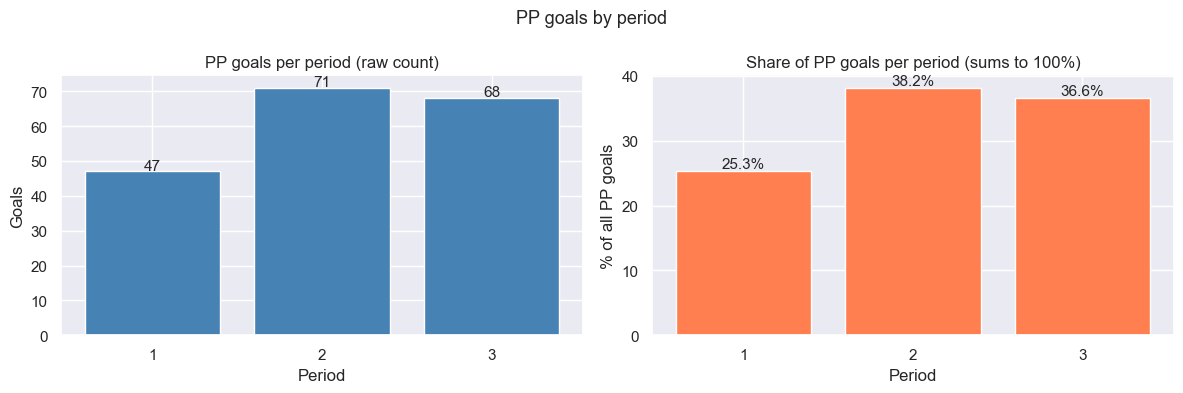

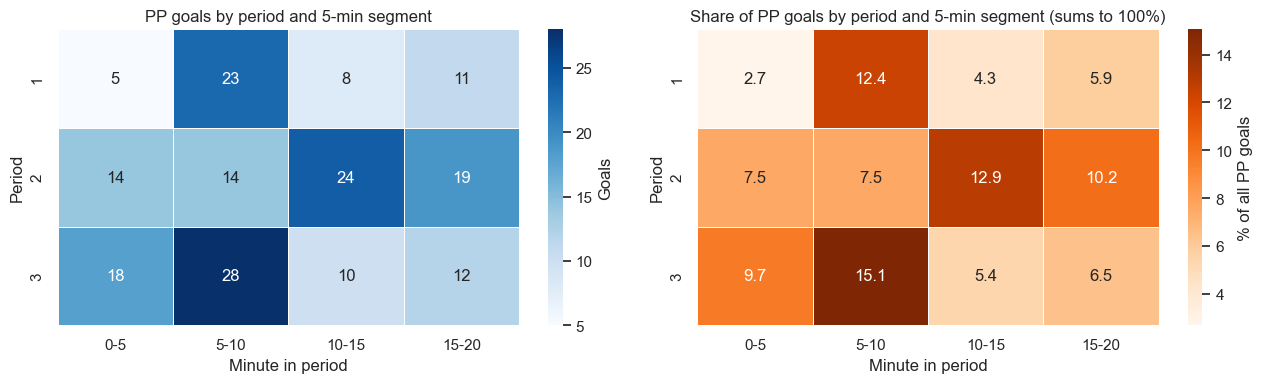

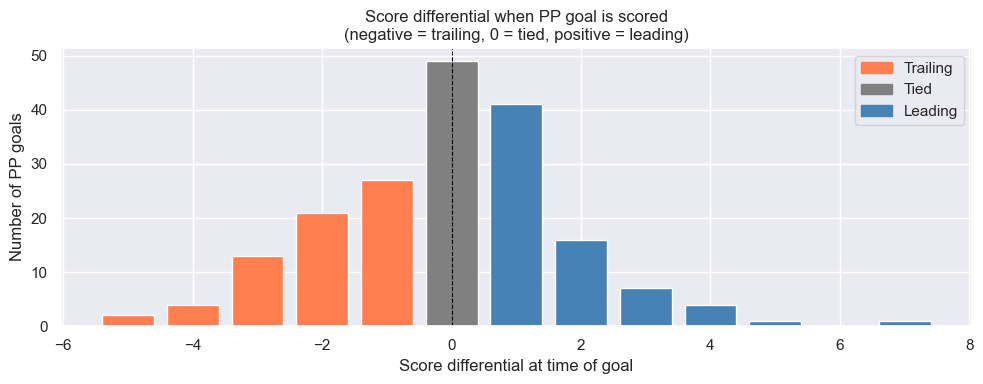

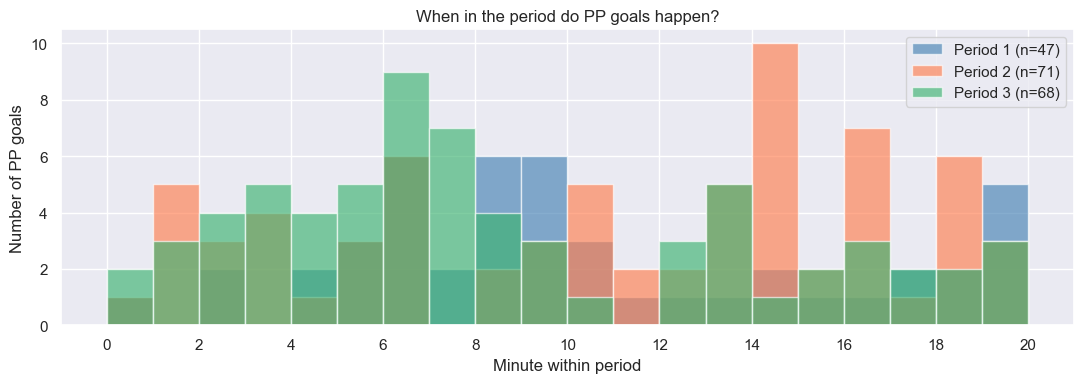

In [28]:
pp_goals = data[(data["manpowersituation"] == "powerPlay") &
                (data["eventname"] == "goal") &
                (data["period"].isin([1, 2, 3]))].copy()

pp_all = data[(data["manpowersituation"] == "powerPlay") &
              (data["period"].isin([1, 2, 3]))].copy()

# compiledgametime is cumulative across the full game
for df in [pp_goals, pp_all]:
    df["time_in_period_s"] = df["compiledgametime"] - (df["period"] - 1) * 1200
    df["minute_in_period"] = df["time_in_period_s"] / 60
    df["5min_bin"] = (df["minute_in_period"] // 5 * 5).clip(0, 15).astype(int)
    df["5min_label"] = df["5min_bin"].astype(str) + "-" + (df["5min_bin"] + 5).astype(str)

goals_per_period = pp_goals["period"].value_counts().sort_index()
share_per_period = goals_per_period / goals_per_period.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(goals_per_period.index, goals_per_period.values, color="steelblue", edgecolor="white")
axes[0].set_title("PP goals per period (raw count)")
axes[0].set_xlabel("Period")
axes[0].set_ylabel("Goals")
axes[0].set_xticks([1, 2, 3])
for i, v in zip(goals_per_period.index, goals_per_period.values):
    axes[0].text(i, v + 0.5, str(v), ha="center", fontsize=11)

axes[1].bar(share_per_period.index, share_per_period.values, color="coral", edgecolor="white")
axes[1].set_title("Share of PP goals per period (sums to 100%)")
axes[1].set_xlabel("Period")
axes[1].set_ylabel("% of all PP goals")
axes[1].set_xticks([1, 2, 3])
for i, v in zip(share_per_period.index, share_per_period.values):
    axes[1].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=11)

plt.suptitle("PP goals by period", fontsize=13)
plt.tight_layout()
plt.show()

bin_labels = ["0-5", "5-10", "10-15", "15-20"]
goal_matrix = pp_goals.groupby(["period", "5min_label"]).size().unstack(fill_value=0)
goal_matrix = goal_matrix.reindex(columns=bin_labels, fill_value=0)

event_matrix = pp_all.groupby(["period", "5min_label"]).size().unstack(fill_value=0)
event_matrix = event_matrix.reindex(columns=bin_labels, fill_value=0)
share_matrix = (goal_matrix / goal_matrix.values.sum() * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.heatmap(goal_matrix, annot=True, fmt="d", cmap="Blues",
            ax=axes[0], linewidths=0.5, cbar_kws={"label": "Goals"})
axes[0].set_title("PP goals by period and 5-min segment")
axes[0].set_xlabel("Minute in period")
axes[0].set_ylabel("Period")

sns.heatmap(share_matrix, annot=True, fmt=".1f", cmap="Oranges",
            ax=axes[1], linewidths=0.5, cbar_kws={"label": "% of all PP goals"})
axes[1].set_title("Share of PP goals by period and 5-min segment (sums to 100%)")
axes[1].set_xlabel("Minute in period")
axes[1].set_ylabel("Period")

plt.tight_layout()
plt.show()

score_counts = pp_goals["scoredifferential"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 4))
colors = ["coral" if x < 0 else "steelblue" if x > 0 else "gray" for x in score_counts.index]
ax.bar(score_counts.index, score_counts.values, color=colors, edgecolor="white")
ax.set_title("Score differential when PP goal is scored\n(negative = trailing, 0 = tied, positive = leading)")
ax.set_xlabel("Score differential at time of goal")
ax.set_ylabel("Number of PP goals")
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="coral", label="Trailing"),
    Patch(color="gray", label="Tied"),
    Patch(color="steelblue", label="Leading")
])
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(11, 4))
period_colors = {1: "steelblue", 2: "coral", 3: "mediumseagreen"}
for p in [1, 2, 3]:
    subset = pp_goals[pp_goals["period"] == p]["minute_in_period"]
    ax.hist(subset, bins=20, range=(0, 20), alpha=0.65,
            label=f"Period {p} (n={len(subset)})", color=period_colors[p], edgecolor="white")
ax.set_title("When in the period do PP goals happen?")
ax.set_xlabel("Minute within period")
ax.set_ylabel("Number of PP goals")
ax.set_xticks(range(0, 21, 2))
ax.legend()
plt.tight_layout()
plt.show()

## When does a powerplay become less effective?